# Chapter 13 — Introducing automatic optimization

> *Grokking Deep Learning* — Andrew W. Trask

Chapter ini membangun **deep learning framework sederhana dari scratch**. Fokus utamanya adalah Tensor, computation graph, automatic gradient computation (**autograd**), parameter optimization, layer abstraction, embedding, cross-entropy, dan recurrent neural network layer.

## Learning Objectives

Setelah menyelesaikan chapter ini, kita diharapkan dapat:

1. Menjelaskan fungsi deep learning framework.
2. Memahami Tensor sebagai abstraksi dari vector, matrix, dan struktur berdimensi lebih tinggi.
3. Menjelaskan bagaimana computation graph digunakan oleh autograd.
4. Memahami gradient accumulation ketika sebuah Tensor digunakan lebih dari satu kali.
5. Menjelaskan bagaimana operator dan fungsi baru ditambahkan ke autograd.
6. Memahami perbedaan training manual dengan training menggunakan autograd.
7. Memahami peran optimizer, layer, Sequential, dan loss-function layer.
8. Memahami bagaimana embedding dan indexing diintegrasikan ke framework.
9. Memahami CrossEntropyLoss dan recurrent neural network layer sebagai abstraksi tingkat tinggi.

## Chapter Roadmap

**Framework → Tensor → Computation Graph → Autograd → Gradient Accumulation → Operations → Optimizer → Layers → Sequential → Loss → Nonlinearity → Embedding → Indexing → Cross Entropy → Recurrent Layer**

Inti chapter ini adalah mengubah proses yang sebelumnya harus ditulis manual menjadi komponen yang dapat digunakan kembali.

## What Is a Deep Learning Framework?

Menurut buku, framework dibuat untuk mengurangi code complexity, mengurangi error, mempercepat development, dan meningkatkan runtime performance. Dua kemampuan yang paling penting adalah **automatic backpropagation** dan **automatic optimization**.

Dengan framework, kita lebih banyak menulis **forward propagation**, sedangkan perhitungan gradient dan weight update ditangani oleh sistem.

In [1]:
# Konsep sederhana: manual training vs framework training
manual_steps = ["Forward propagation", "Hitung loss", "Turunkan gradient", "Update weights"]
framework_steps = ["Forward propagation", "Hitung loss", "backward()", "optimizer.step()"]

print("Manual:", " -> ".join(manual_steps))
print("Framework:", " -> ".join(framework_steps))

Manual: Forward propagation -> Hitung loss -> Turunkan gradient -> Update weights
Framework: Forward propagation -> Hitung loss -> backward() -> optimizer.step()


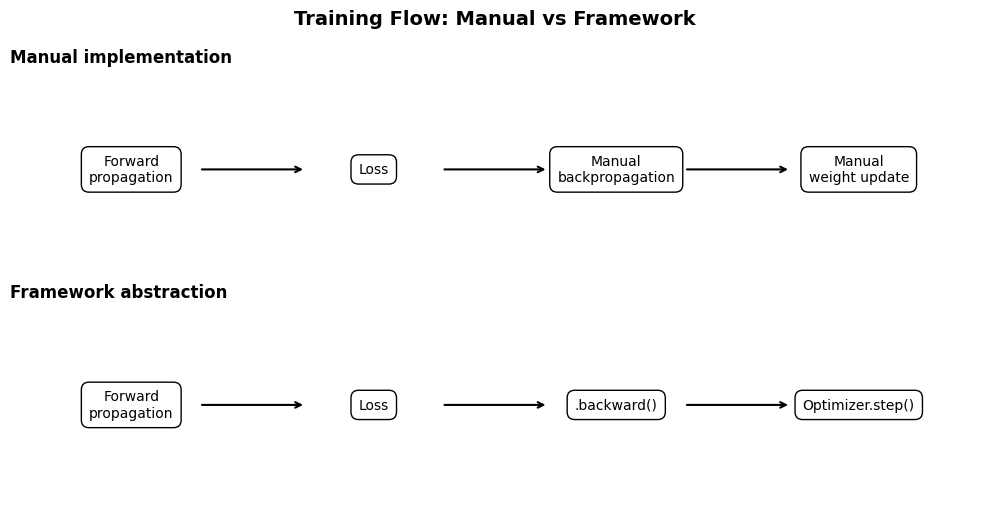

In [2]:
import matplotlib.pyplot as plt

# Perbandingan alur kerja: konsep yang sama, tingkat abstraksi berbeda
fig, axes = plt.subplots(2, 1, figsize=(10, 5.2))

# Manual implementation
axes[0].set_title('Manual implementation', loc='left', fontweight='bold')
steps_manual = ['Forward\npropagation', 'Loss', 'Manual\nbackpropagation', 'Manual\nweight update']
for i, step in enumerate(steps_manual):
    axes[0].text(i, 0, step, ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='black'))
    if i < len(steps_manual) - 1:
        axes[0].annotate('', xy=(i+0.72, 0), xytext=(i+0.28, 0),
                         arrowprops=dict(arrowstyle='->', lw=1.5))

# Framework abstraction
axes[1].set_title('Framework abstraction', loc='left', fontweight='bold')
steps_framework = ['Forward\npropagation', 'Loss', '.backward()', 'Optimizer.step()']
for i, step in enumerate(steps_framework):
    axes[1].text(i, 0, step, ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.55', facecolor='white', edgecolor='black'))
    if i < len(steps_framework) - 1:
        axes[1].annotate('', xy=(i+0.72, 0), xytext=(i+0.28, 0),
                         arrowprops=dict(arrowstyle='->', lw=1.5))

for ax in axes:
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.8, 0.8)
    ax.axis('off')

fig.suptitle('Training Flow: Manual vs Framework', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretasi:** kedua pendekatan tetap mengikuti prinsip *Predict → Compare → Learn*. Perbedaannya terletak pada tingkat abstraksi: pada implementasi manual, backpropagation dan update parameter ditulis secara eksplisit. Pada framework, pekerjaan tersebut ditangani melalui `.backward()` dan optimizer sehingga kode training menjadi lebih ringkas.


## Introduction to Tensors

Buku mendefinisikan Tensor sebagai bentuk abstrak dari nested lists of numbers. Vector adalah **1D Tensor**, matrix adalah **2D Tensor**, sedangkan struktur dengan dimensi lebih tinggi adalah **n-dimensional Tensor**.

In [3]:
import numpy as np

class Tensor:
    def __init__(self, data):
        self.data = np.array(data)

    def __add__(self, other):
        return Tensor(self.data + other.data)

    def __repr__(self):
        return str(self.data.__repr__())

    def __str__(self):
        return str(self.data.__str__())

x = Tensor([1,2,3,4,5])
print(x)
y = x + x
print(y)

[1 2 3 4 5]
[ 2  4  6  8 10]


In [4]:
shapes = {
    "Scalar": (),
    "Vector": (5,),
    "Matrix": (2, 3),
    "3D Tensor": (2, 3, 4)
}

for name, shape in shapes.items():
    print(f"{name:12s} shape = {shape}")

Scalar       shape = ()
Vector       shape = (5,)
Matrix       shape = (2, 3)
3D Tensor    shape = (2, 3, 4)


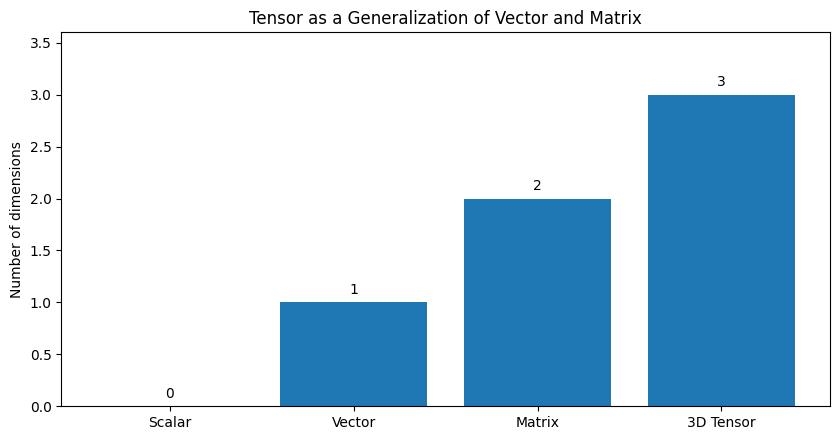

In [5]:
import matplotlib.pyplot as plt

names = ["Scalar", "Vector", "Matrix", "3D Tensor"]
dims = [0, 1, 2, 3]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(names, dims)
ax.set_ylabel('Number of dimensions')
ax.set_title('Tensor as a Generalization of Vector and Matrix')
ax.set_ylim(0, 3.6)
for i, v in enumerate(dims):
    ax.text(i, v + .08, str(v), ha='center')
plt.tight_layout()
plt.show()

## Introduction to Automatic Gradient Computation (Autograd)

Pada implementasi awal, setiap Tensor hanya menyimpan data. Autograd menambahkan informasi tentang **creators** dan **creation operation** sehingga setiap operasi dapat membentuk computation graph.

Contoh `z = x + y` membentuk hubungan dari `z` kembali ke `x` dan `y`. Ketika `z.backward(...)` dipanggil, gradient dapat diteruskan ke node sebelumnya.

In [6]:
# Reproduksi inti autograd untuk operasi addition
import numpy as np

class AutoTensor:
    def __init__(self, data, creators=None, creation_op=None):
        self.data = np.array(data)
        self.creation_op = creation_op
        self.creators = creators
        self.grad = None

    def backward(self, grad):
        self.grad = grad
        if self.creation_op == "add":
            self.creators[0].backward(grad)
            self.creators[1].backward(grad)

    def __add__(self, other):
        return AutoTensor(self.data + other.data,
                          creators=[self, other],
                          creation_op="add")

x = AutoTensor([1,2,3,4,5])
y = AutoTensor([2,2,2,2,2])
z = x + y
z.backward(AutoTensor(np.array([1,1,1,1,1])))

print("z =", z.data)
print("dz/dx =", x.grad.data)
print("dz/dy =", y.grad.data)

z = [3 4 5 6 7]
dz/dx = [1 1 1 1 1]
dz/dy = [1 1 1 1 1]


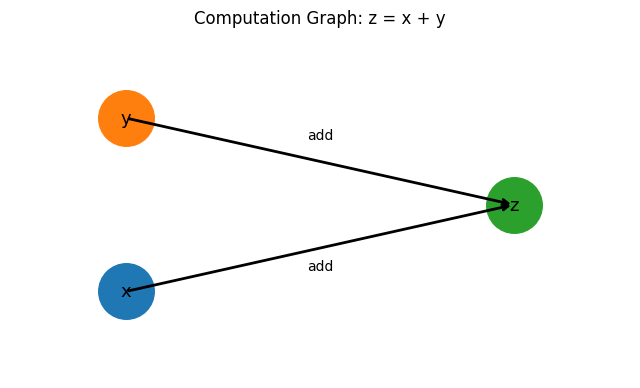

In [7]:
# Visualisasi computation graph z = x + y
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
positions = {'x':(0,0), 'y':(0,1), 'z':(2,.5)}
for label,(xpos,ypos) in positions.items():
    ax.scatter(xpos, ypos, s=1600, zorder=3)
    ax.text(xpos, ypos, label, ha='center', va='center', fontsize=13)
ax.annotate('', xy=positions['z'], xytext=positions['x'], arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=positions['z'], xytext=positions['y'], arrowprops=dict(arrowstyle='->', lw=2))
ax.text(1, .12, 'add', ha='center')
ax.text(1, .88, 'add', ha='center')
ax.set_xlim(-.6,2.6); ax.set_ylim(-.5,1.5); ax.axis('off')
ax.set_title('Computation Graph: z = x + y')
plt.show()

## A Quick Checkpoint

Autograd tidak sekadar menyimpan nilai. Ia menyimpan hubungan antar Tensor sehingga gradient dapat ditelusuri kembali melalui operasi yang membentuk output.

## Tensors That Are Used Multiple Times

Buku menunjukkan bug penting: sebuah Tensor dapat digunakan lebih dari satu kali dalam forward propagation. Jika gradient langsung ditimpa, hasilnya salah.

Pada contoh `f = (a + b) + (b + c)`, Tensor `b` muncul pada dua jalur. Gradient terhadap `b` harus merupakan **penjumlahan kontribusi dari kedua jalur**.

In [8]:
# Demonstrasi kebutuhan gradient accumulation
# b muncul pada dua jalur: d = a+b dan e=b+c
# Maka kontribusi gradient ke b adalah 1 + 1 = 2.
expected_b_grad = np.ones(5) + np.ones(5)
print("Expected gradient for b:", expected_b_grad)

Expected gradient for b: [2. 2. 2. 2. 2.]


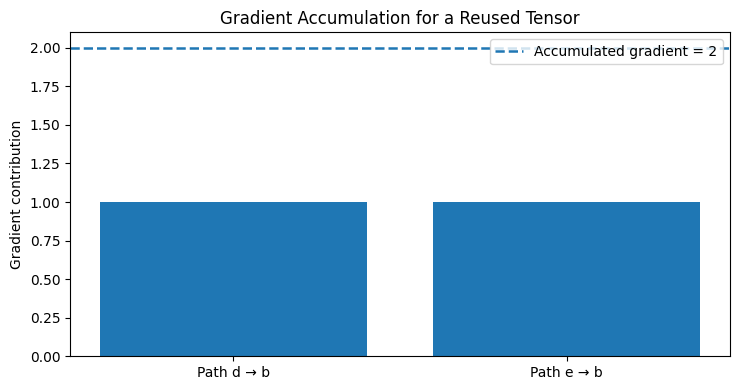

In [9]:
import matplotlib.pyplot as plt

contrib = [1, 1]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(["Path d → b", "Path e → b"], contrib)
ax.axhline(2, linestyle='--', linewidth=1.8, label='Accumulated gradient = 2')
ax.set_ylabel('Gradient contribution')
ax.set_title('Gradient Accumulation for a Reused Tensor')
ax.legend()
plt.tight_layout(); plt.show()

## Upgrading Autograd to Support Multiuse Tensors

Solusi buku adalah menambahkan mekanisme untuk:

- menghitung berapa child yang masih harus mengirim gradient,
- menunggu seluruh kontribusi gradient yang diperlukan,
- mengakumulasi gradient dengan penjumlahan, bukan overwrite,
- mencegah backpropagation ganda dari child yang sama.

In [10]:
# Inti mekanisme accumulation yang diperkenalkan buku
class GradientAccumulator:
    def __init__(self):
        self.grad = None

    def add(self, grad):
        if self.grad is None:
            self.grad = np.array(grad)
        else:
            self.grad += np.array(grad)

acc = GradientAccumulator()
acc.add(np.ones(5))
acc.add(np.ones(5))
print(acc.grad)

[2. 2. 2. 2. 2.]


## How Does Addition Backpropagation Work?

Setelah abstraction dibuat, penambahan operasi baru cukup mengikuti pola yang sama: tentukan bagaimana forward operation bekerja dan tentukan bagaimana gradient diteruskan ke `creators`.

In [11]:
# Reproduksi pola backward untuk addition
class AddRule:
    @staticmethod
    def backward(grad, creators):
        creators[0].backward(grad)
        creators[1].backward(grad)

print("Addition sends the incoming gradient to both creators.")

Addition sends the incoming gradient to both creators.


## Adding Support for Negation

Negation memiliki satu creator. Jika `y = -x`, maka gradient yang diteruskan ke `x` juga dinegasikan.

In [12]:
# Reproduksi inti operator negation
class NegTensor(AutoTensor):
    def __neg__(self):
        return NegTensor(self.data * -1,
                         creators=[self],
                         creation_op="neg")

x = NegTensor([1., 2., 3.])
y = -x
print("y =", y.data)

y = [-1. -2. -3.]


## Adding Support for Additional Functions

Chapter kemudian memperluas Tensor dengan operasi seperti matrix multiplication, sum, expand, dan fungsi lain yang diperlukan oleh neural network. Setiap operasi harus memiliki aturan forward dan aturan backward yang sesuai.

## Using Autograd to Train a Neural Network

Buku membandingkan training manual dengan training menggunakan autograd. Pada versi manual, kita perlu menyimpan intermediate variables dan menulis rumus gradient. Dengan autograd, computation graph menyimpan informasi tersebut dan `.backward()` menjalankan backpropagation.

In [13]:
# Reproduksi training flow berbasis Tensor dari buku
import numpy as np

np.random.seed(0)
data = np.array([[0,0],[0,1],[1,0],[1,1]])
target = np.array([[0],[1],[0],[1]])
weights_0_1 = np.random.rand(2,3)
weights_1_2 = np.random.rand(3,1)
manual_losses = []

for i in range(10):
    layer_1 = data.dot(weights_0_1)
    layer_2 = layer_1.dot(weights_1_2)
    diff = (layer_2 - target)
    sqdiff = (diff * diff)
    loss = sqdiff.sum(0)
    layer_1_grad = diff.dot(weights_1_2.transpose())
    weight_1_2_update = layer_1.transpose().dot(diff)
    weight_0_1_update = data.transpose().dot(layer_1_grad)
    weights_1_2 -= weight_1_2_update * 0.1
    weights_0_1 -= weight_0_1_update * 0.1
    manual_losses.append(float(loss[0]))

print(manual_losses)

[5.066439994622396, 0.4959907791902341, 0.4180671892167177, 0.35298133007809646, 0.2972549636567376, 0.24923260381633278, 0.20785392075862477, 0.17231260916265181, 0.14193744536652994, 0.11613979792168387]


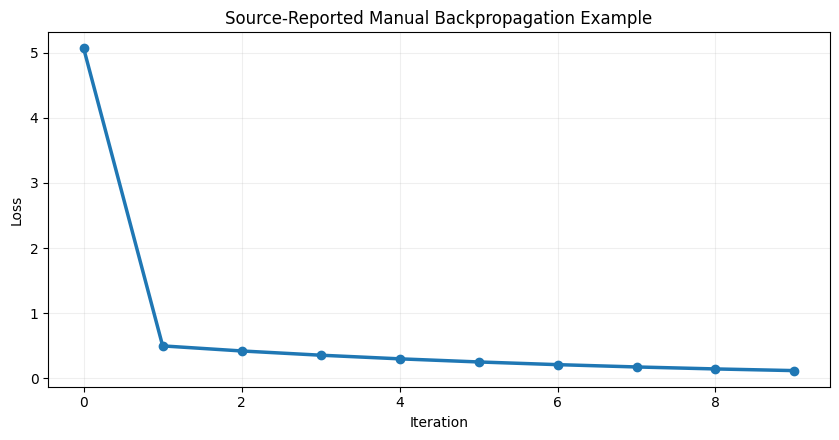

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(range(10), manual_losses, marker='o', linewidth=2.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Source-Reported Manual Backpropagation Example')
ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

**Interpretasi:** loss turun dari sekitar `0.452` menjadi sekitar `0.052` pada 10 iteration. Ini menunjukkan bahwa weight update berhasil mengurangi error pada toy problem yang digunakan buku.

## Adding Automatic Optimization

Setelah autograd tersedia, optimizer dapat dibuat sebagai komponen terpisah. Buku memperkenalkan pola sederhana **SGD**: setiap parameter dikurangi dengan `gradient × alpha`.

In [15]:
class SGD:
    def __init__(self, parameters, alpha=0.1):
        self.parameters = parameters
        self.alpha = alpha

    def zero(self):
        for p in self.parameters:
            p.grad.data *= 0

    def step(self, zero=True):
        for p in self.parameters:
            p.data -= p.grad.data * self.alpha
            if zero:
                p.grad.data *= 0

print("SGD abstraction: parameters -> gradient -> parameter update")

SGD abstraction: parameters -> gradient -> parameter update


## Adding Support for Layer Types

Framework membutuhkan abstraction layer agar forward propagation dapat ditulis secara konsisten. Buku membuat `Layer` sebagai base class dan `Linear` sebagai contoh layer dengan weight dan bias.

In [16]:
class Layer:
    def __init__(self):
        self.parameters = []

    def get_parameters(self):
        return self.parameters

class Linear(Layer):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()
        W = np.random.randn(n_inputs, n_outputs) * np.sqrt(2.0 / n_inputs)
        self.weight = Tensor(W)
        self.bias = Tensor(np.zeros(n_outputs))
        self.parameters.append(self.weight)
        self.parameters.append(self.bias)

    def forward(self, input):
        return Tensor(input.data.dot(self.weight.data) + self.bias.data)

layer = Linear(2, 3)
print("Weight shape:", layer.weight.data.shape)
print("Bias shape:", layer.bias.data.shape)

Weight shape: (2, 3)
Bias shape: (3,)


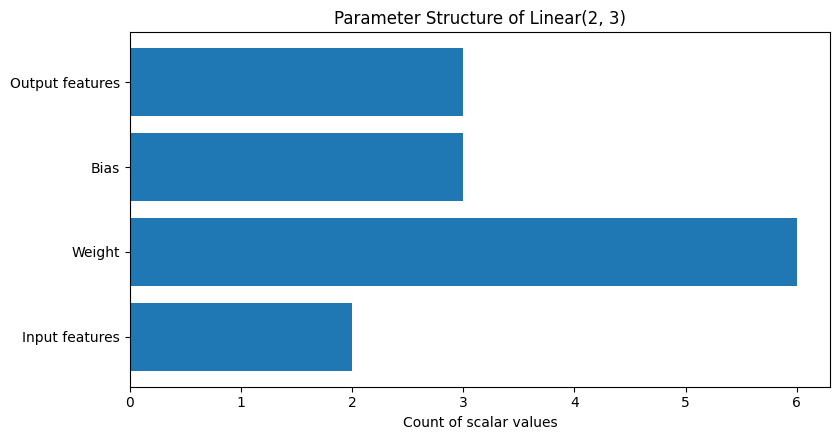

In [17]:
import matplotlib.pyplot as plt

components = ['Input features', 'Weight', 'Bias', 'Output features']
values = [2, 6, 3, 3]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.barh(components, values)
ax.set_xlabel('Count of scalar values')
ax.set_title('Parameter Structure of Linear(2, 3)')
plt.tight_layout(); plt.show()

## Layers That Contain Layers

`Sequential` membuat beberapa layer dapat dirangkai. Output dari satu layer menjadi input bagi layer berikutnya, sedangkan `get_parameters()` mengumpulkan seluruh parameter dari layer yang berada di dalamnya.

In [18]:
class Sequential(Layer):
    def __init__(self, layers=None):
        super().__init__()
        self.layers = layers or []

    def add(self, layer):
        self.layers.append(layer)

    def forward(self, input):
        for layer in self.layers:
            input = layer.forward(input)
        return input

    def get_parameters(self):
        params = []
        for layer in self.layers:
            params += layer.get_parameters()
        return params

model = Sequential([Linear(2,3), Linear(3,1)])
print("Number of parameter tensors:", len(model.get_parameters()))

Number of parameter tensors: 4


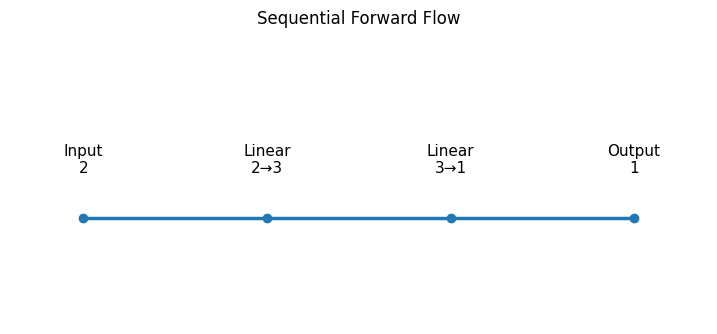

In [19]:
import matplotlib.pyplot as plt

layers = ['Input\n2', 'Linear\n2→3', 'Linear\n3→1', 'Output\n1']
x = np.arange(len(layers))
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(x, [1]*len(x), marker='o', linewidth=2.5)
for i, label in enumerate(layers):
    ax.text(i, 1.08, label, ha='center', va='bottom', fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(-.4, 3.4); ax.set_ylim(.8,1.35)
ax.set_title('Sequential Forward Flow')
ax.axis('off')
plt.show()

## Loss-Function Layers

Tidak semua layer mempunyai parameter. `MSELoss` adalah contoh layer yang hanya menjalankan fungsi pada input prediction dan target. Parameter model tetap diperbarui melalui gradient yang dihasilkan loss.

In [20]:
class MSELoss(Layer):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        return Tensor(((pred.data - target.data) ** 2).sum(0))

criterion = MSELoss()
print("MSELoss parameters:", criterion.get_parameters())

MSELoss parameters: []


## How to Learn a Framework

Buku merangkum framework secara sederhana sebagai **autograd + kumpulan prebuilt layers + optimizers**. Memahami abstraction ini membantu kita berpindah ke framework nyata seperti PyTorch karena konsep dasarnya tetap sama.

## Nonlinearity Layers

Nonlinearity dapat dikemas sebagai layer sehingga model dapat ditulis secara modular. Contohnya `Tanh` atau `Sigmoid`. Abstraction ini membuat fungsi aktivasi dapat dipasang di antara layer tanpa menulis ulang seluruh training loop.

In [21]:
class Tanh(Layer):
    def forward(self, input):
        return Tensor(np.tanh(input.data))

x = Tensor(np.array([[-2., -1., 0., 1., 2.]]))
y = Tanh().forward(x)
print(y.data)

[[-0.96402758 -0.76159416  0.          0.76159416  0.96402758]]


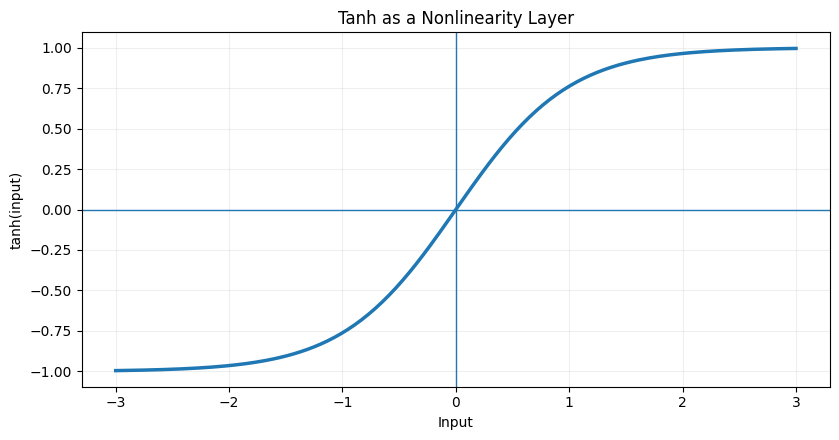

In [22]:
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 200)
y = np.tanh(x)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(x, y, linewidth=2.5)
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_xlabel('Input')
ax.set_ylabel('tanh(input)')
ax.set_title('Tanh as a Nonlinearity Layer')
ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

## The Embedding Layer

Embedding menyimpan sebuah matrix `weight` yang memetakan index vocabulary menjadi vector. Ini melanjutkan ide Chapter 11, tetapi sekarang embedding dikemas sebagai layer dengan parameter yang dapat dioptimasi.

In [23]:
class Embedding(Layer):
    def __init__(self, vocab_size, dim):
        super().__init__()
        weight = (np.random.rand(vocab_size, dim) - 0.5) / dim
        self.weight = Tensor(weight)
        self.parameters.append(self.weight)

    def forward(self, indices):
        return Tensor(self.weight.data[indices.data])

embed = Embedding(vocab_size=5, dim=3)
indices = Tensor(np.array([1,2,3]))
output = embed.forward(indices)
print("Embedding output shape:", output.data.shape)

Embedding output shape: (3, 3)


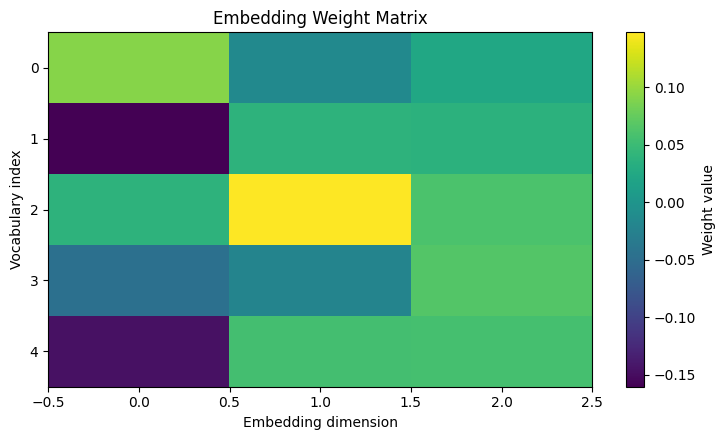

In [24]:
import matplotlib.pyplot as plt

matrix = embed.weight.data
fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(matrix, aspect='auto')
ax.set_xlabel('Embedding dimension')
ax.set_ylabel('Vocabulary index')
ax.set_title('Embedding Weight Matrix')
fig.colorbar(im, ax=ax, label='Weight value')
plt.tight_layout(); plt.show()

## Adding Indexing to Autograd

Agar embedding dapat belajar, autograd harus mengetahui baris mana yang dipilih saat forward propagation. Saat backward, gradient dikembalikan ke row yang sesuai. Jika sebuah index muncul beberapa kali, kontribusinya dijumlahkan pada row yang sama.

In [25]:
# Demonstrasi hasil indexing dan akumulasi gradient secara langsung
x = np.eye(5)
indices = np.array([[1,2,3],[2,3,4]])
selected = x[indices]
print("Selected shape:", selected.shape)

new_grad = np.zeros_like(x)
for idx in indices.flatten():
    new_grad[idx] += 1
print("Gradient accumulated per row:")
print(new_grad)

Selected shape: (2, 3, 5)
Gradient accumulated per row:
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2.]
 [1. 1. 1. 1. 1.]]


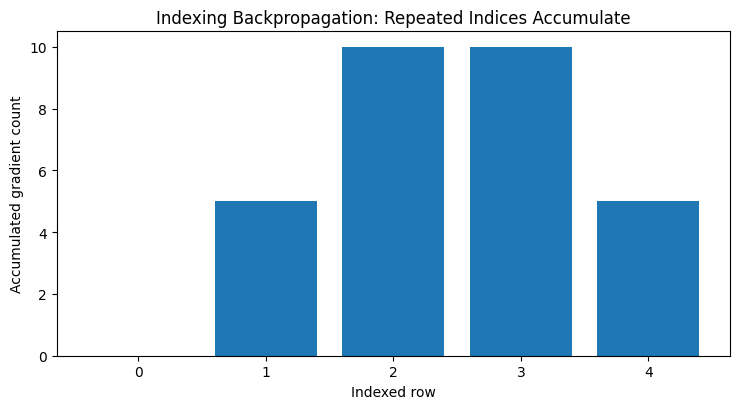

In [26]:
import matplotlib.pyplot as plt

row_grad = new_grad.sum(axis=1)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(np.arange(5), row_grad)
ax.set_xticks(np.arange(5), ['0','1','2','3','4'])
ax.set_xlabel('Indexed row')
ax.set_ylabel('Accumulated gradient count')
ax.set_title('Indexing Backpropagation: Repeated Indices Accumulate')
plt.tight_layout(); plt.show()

## The Embedding Layer (Revisited)

Setelah `index_select` tersedia di autograd, `Embedding.forward()` dapat menggunakan operasi tersebut sehingga gradient dapat kembali ke row embedding yang benar.

## The Cross-Entropy Layer

Cross entropy menggabungkan softmax dengan negative log-likelihood untuk menghasilkan loss klasifikasi. Buku mengimplementasikannya sebagai layer sehingga model cukup memanggil `criterion.forward(output, target)` dan autograd menangani gradient.

In [27]:
class CrossEntropyLoss(Layer):
    def __init__(self):
        super().__init__()

    def forward(self, logits, target_indices):
        x = logits.data
        x = x - np.max(x, axis=-1, keepdims=True)
        p = np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)
        t = target_indices.data.flatten()
        loss = -np.log(p[np.arange(len(t)), t]).mean()
        return Tensor(np.array(loss))

logits = Tensor(np.array([[2.0, 0.5, -1.0], [0.2, 1.5, 0.1]]))
target = Tensor(np.array([0,1]))
loss = CrossEntropyLoss().forward(logits, target)
print("Cross entropy:", loss.data)

Cross entropy: 0.3297241404905412


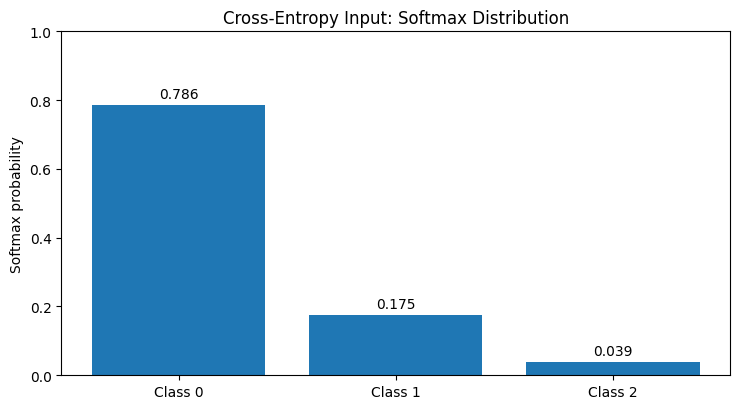

In [28]:
import matplotlib.pyplot as plt

logits = np.array([2.0, 0.5, -1.0])
probs = np.exp(logits - logits.max())
probs /= probs.sum()
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['Class 0','Class 1','Class 2'], probs)
ax.set_ylabel('Softmax probability')
ax.set_title('Cross-Entropy Input: Softmax Distribution')
for i,p in enumerate(probs): ax.text(i,p+.02,f'{p:.3f}',ha='center')
ax.set_ylim(0,1)
plt.tight_layout(); plt.show()

## The Recurrent Neural Network Layer

Di bagian akhir chapter, framework digunakan untuk membungkus recurrent computation menjadi layer. Buku menunjukkan bahwa network pada Chapter 12 dapat ditulis jauh lebih sederhana karena detail forward, backward, dan parameter update telah diabstraksikan oleh framework.

In [29]:
# Struktur recurrent layer yang menjadi dasar contoh buku
class RNNCell(Layer):
    def __init__(self, n_inputs, n_hidden, n_output):
        super().__init__()
        self.n_inputs = n_inputs
        self.n_hidden = n_hidden
        self.n_output = n_output
        self.w_ih = Tensor(np.random.randn(n_inputs, n_hidden) * 0.05)
        self.w_hh = Tensor(np.random.randn(n_hidden, n_hidden) * 0.05)
        self.w_ho = Tensor(np.random.randn(n_hidden, n_output) * 0.05)
        self.parameters += [self.w_ih, self.w_hh, self.w_ho]

    def init_hidden(self, batch_size):
        return Tensor(np.zeros((batch_size, self.n_hidden)))

    def forward(self, input, hidden):
        h = np.tanh(input.data.dot(self.w_ih.data) + hidden.data.dot(self.w_hh.data))
        out = h.dot(self.w_ho.data)
        return Tensor(out), Tensor(h)

rnn = RNNCell(n_inputs=4, n_hidden=5, n_output=3)
h = rnn.init_hidden(batch_size=2)
out, h2 = rnn.forward(Tensor(np.random.randn(2,4)), h)
print("Hidden shape:", h2.data.shape)
print("Output shape:", out.data.shape)

Hidden shape: (2, 5)
Output shape: (2, 3)


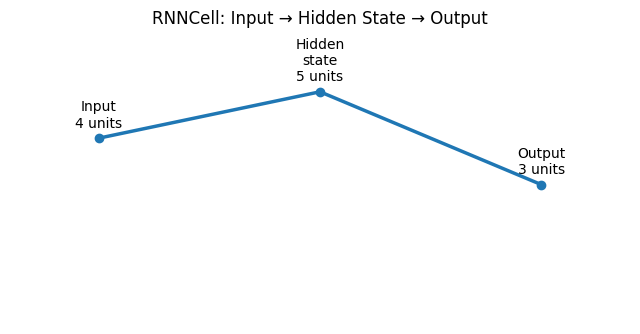

In [30]:
import matplotlib.pyplot as plt

sizes = [4, 5, 3]
labels = ['Input', 'Hidden\nstate', 'Output']
x = [0,1,2]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(x, sizes, marker='o', linewidth=2.5)
for xi, yi, lab in zip(x, sizes, labels):
    ax.text(xi, yi+.25, f'{lab}\n{yi} units', ha='center')
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(-.4,2.4); ax.set_ylim(0,6.3)
ax.set_title('RNNCell: Input → Hidden State → Output')
ax.axis('off')
plt.show()

## Putting the Framework Pieces Together

Framework abstraction memungkinkan model ditulis sebagai kombinasi layer, loss, dan optimizer. Ini adalah perubahan utama dibandingkan chapter sebelumnya: kompleksitas matematis tetap ada, tetapi interface untuk menggunakannya menjadi jauh lebih ringkas.

In [31]:
# Arsitektur tingkat tinggi seperti yang digunakan framework
architecture = [
    'Embedding',
    'RNNCell',
    'CrossEntropyLoss',
    'SGD'
]
for i, component in enumerate(architecture, 1):
    print(f'{i}. {component}')

1. Embedding
2. RNNCell
3. CrossEntropyLoss
4. SGD


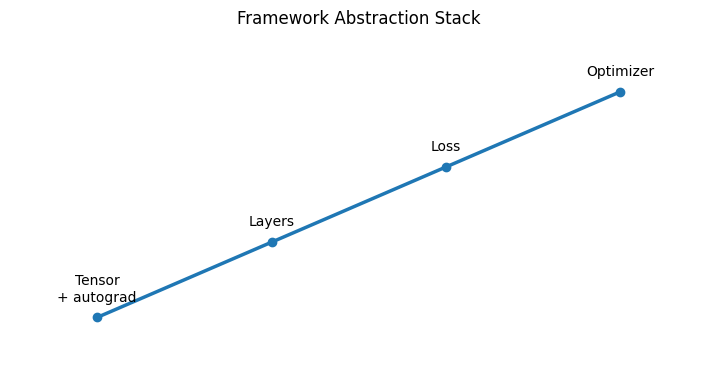

In [32]:
import matplotlib.pyplot as plt

roles = ['Tensor\n+ autograd', 'Layers', 'Loss', 'Optimizer']
levels = [1,2,3,4]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(levels, [1,2,3,4], marker='o', linewidth=2.5)
for x, y, role in zip(levels, levels, roles):
    ax.text(x, y+.18, role, ha='center', va='bottom')
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(.5,4.5); ax.set_ylim(.5,4.8)
ax.set_title('Framework Abstraction Stack')
ax.axis('off')
plt.show()

## Concept Check

| Pertanyaan | Inti Jawaban |
|---|---|
| Apa fungsi framework? | Mengurangi code complexity dan menyediakan abstraction untuk training. |
| Apa itu Tensor? | Abstraksi dari vector, matrix, dan struktur berdimensi lebih tinggi. |
| Mengapa computation graph diperlukan? | Agar autograd mengetahui hubungan antar operasi saat backward. |
| Mengapa gradient perlu diakumulasi? | Karena satu Tensor dapat digunakan oleh lebih dari satu child. |
| Apa fungsi optimizer? | Menggunakan gradient untuk memperbarui parameter. |
| Mengapa ada Layer abstraction? | Agar operasi forward dan parameter dapat digunakan kembali secara modular. |
| Mengapa indexing penting untuk embedding? | Agar gradient kembali ke row embedding yang benar. |
| Apa inti framework menurut buku? | Autograd + prebuilt layers + optimizers. |

## Key Takeaways

- **Tensor** menjadi struktur data dasar framework.
- **Computation graph** menyimpan hubungan antar operasi.
- **Autograd** mengotomatisasi backpropagation.
- Gradient dari penggunaan Tensor berulang harus **diakumulasi**.
- **SGD** memisahkan parameter update dari model definition.
- **Layer** dan **Sequential** membuat model lebih modular.
- **Embedding**, **CrossEntropyLoss**, dan **RNNCell** menunjukkan bagaimana framework dapat menyediakan abstraction tingkat tinggi.
- Tujuan akhirnya bukan menghilangkan matematika, tetapi membuat implementasi model kompleks lebih ringkas, reusable, dan lebih mudah dikembangkan.

## Chapter Summary

Chapter 13 memindahkan kita dari implementasi neural network secara manual menuju cara kerja deep learning framework. Kita membangun Tensor, membuat computation graph, mengotomatisasi gradient dengan autograd, memperbaiki gradient accumulation, menambahkan optimizer, kemudian membungkus operasi menjadi layer. Framework yang sama akhirnya dapat menyediakan embedding, cross entropy, dan recurrent layer.

Dengan memahami mekanisme ini, penggunaan framework seperti PyTorch menjadi lebih mudah dipahami karena abstraction yang digunakan tidak lagi terasa sebagai black box.

## Reference

Andrew W. Trask. *Grokking Deep Learning*. Manning Publications.

Chapter 13: **Introducing automatic optimization: let’s build a deep learning framework**, pp. 231–263.